In [2]:
!pip install yfinance

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np


In [5]:
stocks = [
    "aapl",
    "msft",
    "googl",
    "amzn",
    "tsla"
]

In [8]:
data = yf.download(
    stocks,
    start ="2020-01-01",
    end ="2025-01-01"
)
data.head()

/tmp/ipykernel_641/1017274496.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  5 of 5 completed


Price           Close                                                    High  \
Ticker           AAPL       AMZN      GOOGL        MSFT       TSLA       AAPL   
Date                                                                            
2020-01-02  72.333878  94.900497  67.832512  151.829559  28.684000  72.394086   
2020-01-03  71.630646  93.748497  67.477661  149.938980  29.534000  72.389265   
2020-01-06  72.201408  95.143997  69.276215  150.326553  30.102667  72.239942   
2020-01-07  71.861855  95.343002  69.142395  148.955917  31.270666  72.466338   
2020-01-08  73.017838  94.598503  69.634537  151.328568  32.809334  73.318877   

Price                                                    ...       Open  \
Ticker           AMZN      GOOGL        MSFT       TSLA  ...       AAPL   
Date                                                     ...              
2020-01-02  94.900497  67.832512  151.933540  28.713333  ...  71.344054   
2020-01-03  94.309998  68.083790  151.196193  30.266666  ...  71.563213   
2020-01-06  95.184502  69.301488  150.392729  30.104000  ...  70.754014   
2020-01-07  95.694504  69.558210  150.931532  31.441999  ...  72.211056   
2020-01-08  95.550003  69.972044  151.999717  33.232666  ...  71.565621   

Price                                                       Volume            \
Ticker           AMZN      GOOGL        MSFT       TSLA       AAPL      AMZN   
Date                                                                           
2020-01-02  93.750000  66.827923  150.090263  28.299999  135480400  80580000   
2020-01-03  93.224998  66.807608  149.655410  29.366667  146322800  75288000   
2020-01-06  93.000000  66.987503  148.483276  29.364668  118387200  81236000   
2020-01-07  95.224998  69.407546  150.600695  30.760000  108872000  80898000   
2020-01-08  94.902000  69.128026  150.232049  31.580000  132079200  70160000   

Price                                      
Ticker         GOOGL      MSFT       TSLA  
Date                                       
2020-01-02  27278000  22622100  142981500  
2020-01-03  23408000  21116200  266677500  
2020-01-06  46768000  20813700  151995000  
2020-01-07  34330000  21634100  268231500  
2020-01-08  35314000  27746500  467164500  

[5 rows x 25 columns]

In [14]:
prices = data["Close"]
prices.head()

Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2020-01-02,72.333878,94.900497,67.832512,151.829559,28.684000
2020-01-03,71.630646,93.748497,67.477661,149.938980,29.534000
2020-01-06,72.201408,95.143997,69.276215,150.326553,30.102667
2020-01-07,71.861855,95.343002,69.142395,148.955917,31.270666
2020-01-08,73.017838,94.598503,69.634537,151.328568,32.809334


In [16]:
returns = prices.pct_change().dropna()
returns.head()


Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2020-01-03,-0.009722,-0.012139,-0.005231,-0.012452,0.029633
2020-01-06,0.007968,0.014886,0.026654,0.002585,0.019255
2020-01-07,-0.004703,0.002092,-0.001932,-0.009118,0.038801
2020-01-08,0.016086,-0.007809,0.007118,0.015929,0.049205
2020-01-09,0.021241,0.004799,0.010498,0.012493,-0.021945


In [17]:
mean_returns = returns.mean()
print(mean_returns)

Ticker
AAPL     0.001182
AMZN     0.000923
GOOGL    0.001022
MSFT     0.000988
TSLA     0.002997
dtype: float64


In [18]:
risk = returns.std()
print(risk)

Ticker
AAPL     0.019956
AMZN     0.022655
GOOGL    0.020472
MSFT     0.019211
TSLA     0.042320
dtype: float64


In [19]:
num_portfolios = 5000

results = []

for i in range(num_portfolios):

    weights = np.random.random(len(stocks))
    weights = weights / np.sum(weights)

    portfolio_return = np.sum(mean_returns * weights) * 252

    portfolio_risk = np.sqrt(
        np.dot(
            weights.T,
            np.dot(returns.cov() * 252, weights)
        )
    )

    sharpe_ratio = portfolio_return / portfolio_risk

    results.append([
        portfolio_return,
        portfolio_risk,
        sharpe_ratio,
        *weights
    ])

In [23]:
columns =[
    "returns",
    "risk",
    "sharpe",
    *stocks
]
portfolio_df = pd.DataFrame(
    results,
    columns = columns
)
portfolio_df.head()

,returns,risk,sharpe,aapl,msft,googl,amzn,tsla
0,0.334368,0.304221,1.099097,0.308441,0.218687,0.224717,0.106090,0.142065
1,0.298905,0.289656,1.031930,0.334775,0.143693,0.326315,0.129876,0.065341
2,0.261543,0.301970,0.866121,0.188439,0.508016,0.280451,0.004890,0.018205
3,0.349969,0.317810,1.101189,0.211322,0.301115,0.082341,0.217874,0.187349
4,0.345048,0.310142,1.112547,0.239503,0.214646,0.142684,0.232070,0.171096


In [28]:
best_portfolio = portfolio_df.loc[
    portfolio_df["sharpe"].idxmax()
]
best_portfolio

,1665
returns,0.474507
risk,0.389198
sharpe,1.219194
aapl,0.335546
msft,0.005016
googl,0.236563
amzn,0.013772
tsla,0.409104


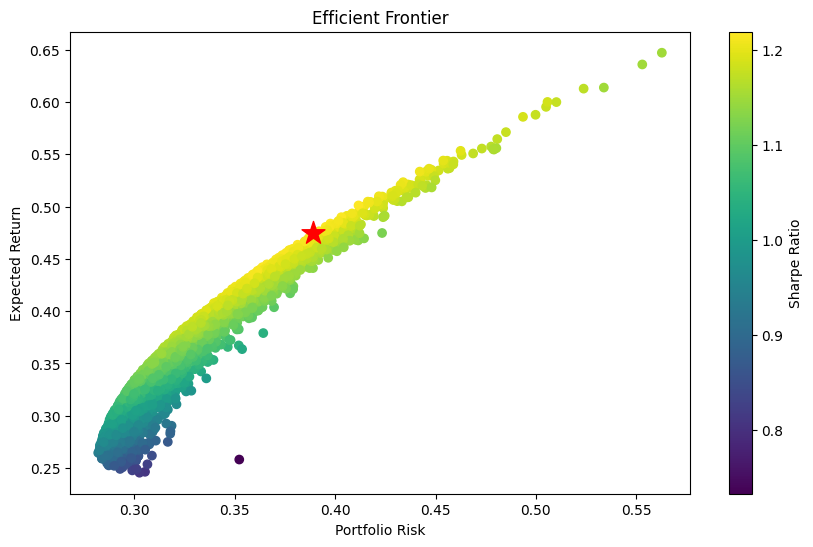

In [30]:
plt.figure(figsize=(10,6))

plt.scatter(
    portfolio_df["risk"],
    portfolio_df["returns"],
    c=portfolio_df["sharpe"],
    cmap="viridis"
)

plt.colorbar(label="Sharpe Ratio")

plt.scatter(
    best_portfolio["risk"],
    best_portfolio["returns"],
    color="red",
    s=300,
    marker="*"
)

plt.xlabel("Portfolio Risk")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier")

plt.show()